In [8]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Upload Dataset

from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [9]:
# 3. Load Dataset

df = pd.read_excel("Online Retail.xlsx")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
# 4. Check Dataset Information

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 541909
Columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [11]:
# 5. Check Missing Values

print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [12]:
# 6. Check Duplicate Values

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5268


In [13]:
# 7. Check Statistical Summary

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [14]:
# 8. Check Duplicate Rows

duplicate_rows = df[df.duplicated(keep=False)]

print("Total Duplicate Rows:", len(duplicate_rows))

duplicate_rows.head(10)

Total Duplicate Rows: 10147


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [16]:
# 9. Remove Duplicates

df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 536641


In [17]:
# 10. Check Missing Description

missing_description = df[df["Description"].isnull()]

print("Missing Description:", len(missing_description))
print("UnitPrice = 0:", (missing_description["UnitPrice"] == 0).sum())
print("Missing CustomerID:", missing_description["CustomerID"].isnull().sum())
print("Negative Quantity:", (missing_description["Quantity"] < 0).sum())

Missing Description: 1454
UnitPrice = 0: 1454
Missing CustomerID: 1454
Negative Quantity: 862


In [18]:
# 11. Check Missing Description Invoice

missing_description["InvoiceNo"].astype(str).str.startswith("C").value_counts()

,count
InvoiceNo,
False,1454


In [19]:
# 12. Check Stock Codes

missing_codes = df.loc[
    df["Description"].isnull(),
    "StockCode"
].unique()

known_descriptions = df[
    df["StockCode"].isin(missing_codes) &
    df["Description"].notnull()
]

print("Missing Description Stock Codes:", len(missing_codes))
print(
    "Stock Codes with Known Descriptions:",
    known_descriptions["StockCode"].nunique()
)

Missing Description Stock Codes: 960
Stock Codes with Known Descriptions: 848


In [20]:
# 13. Remove Missing Description

df = df.dropna(subset=["Description"])

print("Rows after removing missing Description:", df.shape[0])

Rows after removing missing Description: 535187


In [21]:
# 14. Check Missing CustomerID

print("Missing CustomerID:", df["CustomerID"].isnull().sum())

Missing CustomerID: 133583


In [22]:
# 15. Remove Missing CustomerID

df = df.dropna(subset=["CustomerID"])

print("Rows after removing missing CustomerID:", df.shape[0])

Rows after removing missing CustomerID: 401604


In [23]:
# 16. Check Invalid Quantity

print("Quantity <= 0:", (df["Quantity"] <= 0).sum())

Quantity <= 0: 8872


In [25]:
# 17. Check Invalid Unit Price

print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

UnitPrice <= 0: 40


In [26]:
# 18. Remove Invalid Transactions

df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

print("Rows after cleaning:", df.shape[0])

Rows after cleaning: 392692


In [27]:
# 19. Create Total Amount

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [28]:
# 20. Calculate Total Revenue

total_revenue = df["TotalAmount"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 8887208.894


In [29]:
# 21. Find Top Products

top_products = (
    df.groupby("Description")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalAmount, dtype: float64


In [30]:
# 22. Find Top Countries

country_sales = (
    df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_sales)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64


In [31]:
# 23. Count Unique Customers

unique_customers = df["CustomerID"].nunique()

print("Total Customers:", unique_customers)

Total Customers: 4338


In [33]:
# 24. Count Unique Products

unique_products = df["StockCode"].nunique()

print("Total Products:", unique_products)

Total Products: 3665


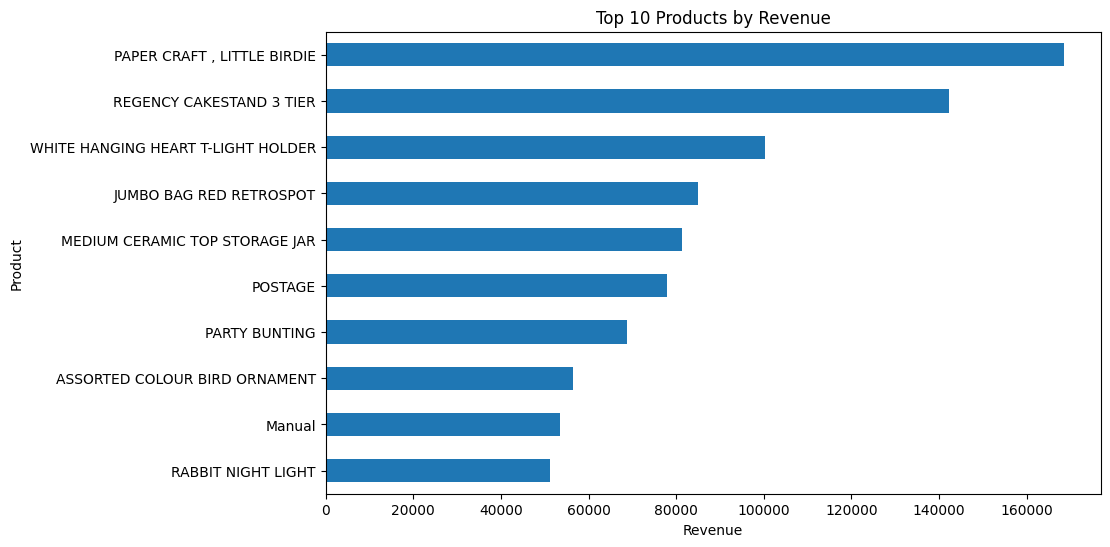

In [34]:
# 25. Plot Top Products

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

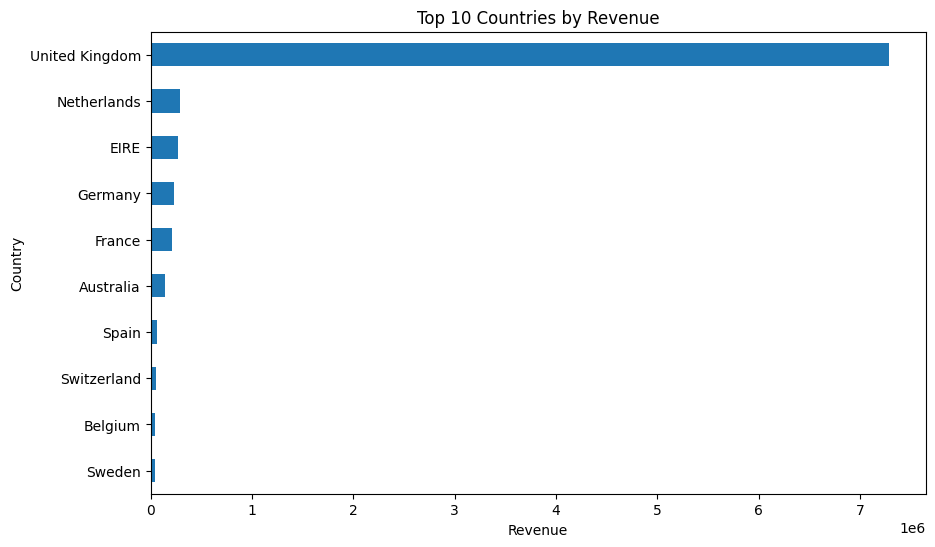

In [35]:
# 26. Plot Top Countries

plt.figure(figsize=(10, 6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()


In [36]:
# 27. Create Month Column

df["Month"] = df["InvoiceDate"].dt.to_period("M")

df[["InvoiceDate", "Month"]].head()

,InvoiceDate,Month
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [37]:
# 28. Monthly Sales

monthly_sales = df.groupby("Month")["TotalAmount"].sum()

print(monthly_sales)

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalAmount, dtype: float64


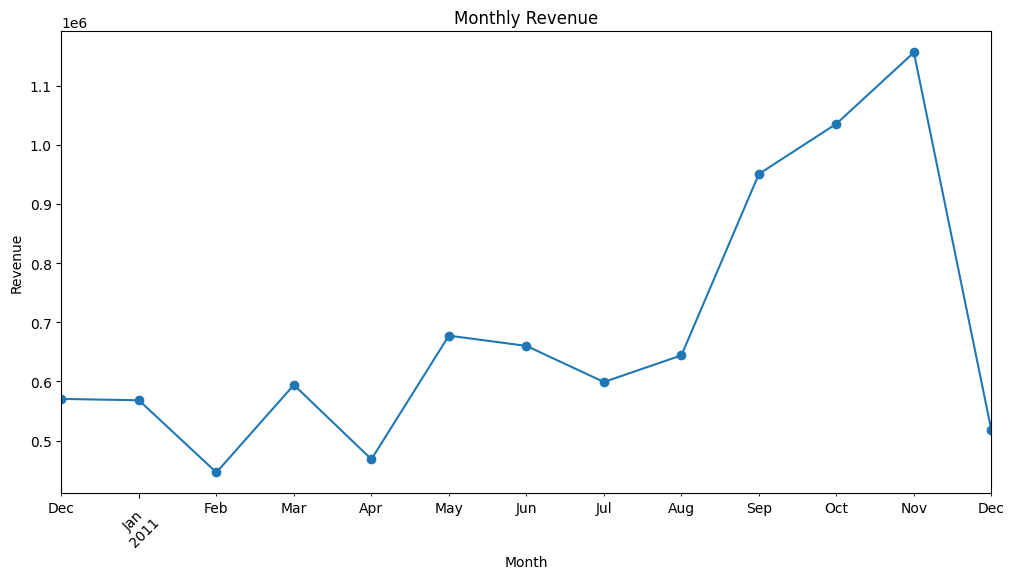

In [38]:
# 29. Plot Monthly Sales

plt.figure(figsize=(12, 6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [39]:
# 30. RFM Analysis

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [40]:
# 31. RFM Summary

rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [41]:
# 32. Scale RFM Data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print("RFM data scaled successfully!")

RFM data scaled successfully!


In [42]:
# 33. K-Means Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed!")

K-Means clustering completed!


In [43]:
# 34. Check Cluster Counts

print(rfm["Cluster"].value_counts().sort_index())

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


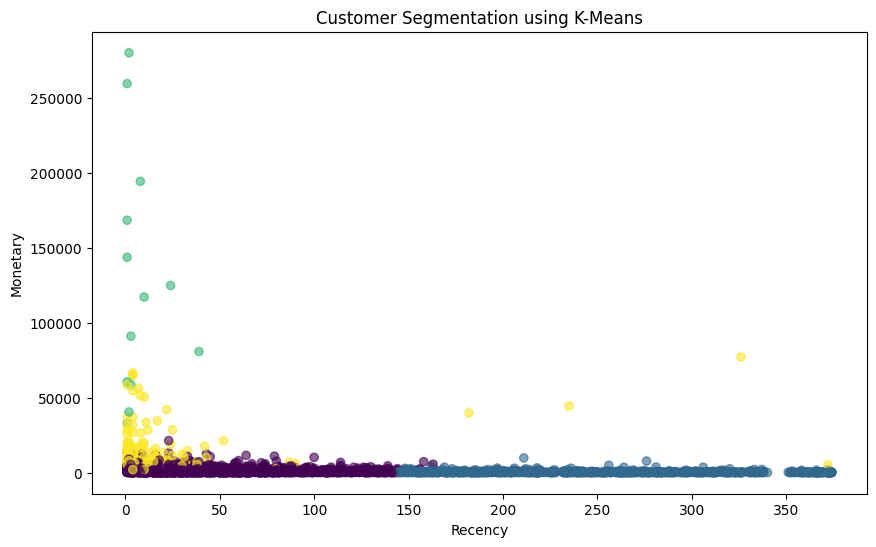

In [44]:
# 35. Visualize Customer Clusters

plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    alpha=0.6
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.show()

In [45]:
# 36. Cluster Profile

cluster_profile = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1353.625312
1        248.075914   1.552015     478.848773
2          7.384615  82.538462  127187.959231
3         15.500000  22.333333   12690.500392


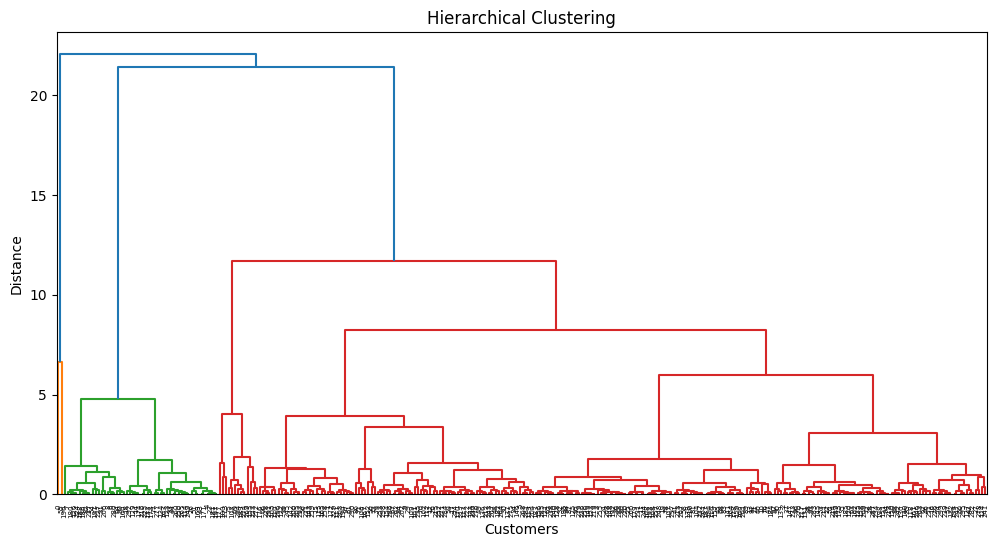

In [46]:
# 37. Hierarchical Clustering

from scipy.cluster.hierarchy import dendrogram, linkage

sample_rfm = rfm_scaled[:300]

linked = linkage(sample_rfm, method="ward")

plt.figure(figsize=(12, 6))

dendrogram(linked)

plt.title("Hierarchical Clustering")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [47]:
# 38. Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=4
)

rfm["Hierarchical_Cluster"] = hierarchical.fit_predict(
    rfm_scaled
)

print("Hierarchical clustering completed!")

Hierarchical clustering completed!


In [48]:
# 39. Hierarchical Cluster Counts

print(
    rfm["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Hierarchical_Cluster
0      15
1    3042
2    1134
3     147
Name: count, dtype: int64


In [49]:
# 40. Compare Clustering Methods

cluster_comparison = pd.crosstab(
    rfm["Cluster"],
    rfm["Hierarchical_Cluster"]
)

print(cluster_comparison)

Hierarchical_Cluster   0     1     2    3
Cluster                                  
0                      0  2987    67    0
1                      0     0  1067    0
2                     13     0     0    0
3                      2    55     0  147


In [50]:
# 41. Split Data Based on Time

cutoff_date = df["InvoiceDate"].max() - pd.Timedelta(days=30)

feature_data = df[
    df["InvoiceDate"] <= cutoff_date
].copy()

future_data = df[
    (df["InvoiceDate"] > cutoff_date) &
    (df["InvoiceDate"] <= df["InvoiceDate"].max())
].copy()

print("Feature Data:", feature_data.shape)
print("Future Data:", future_data.shape)

Feature Data: (328431, 10)
Future Data: (64261, 10)


In [51]:
# 42. Create Customer Features

customer_features = feature_data.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "UnitPrice": "mean",
    "TotalAmount": ["sum", "mean"],
    "InvoiceDate": ["min", "max"]
})

customer_features.columns = [
    "PurchaseFrequency",
    "TotalQuantity",
    "AvgUnitPrice",
    "TotalSpend",
    "AvgTransactionValue",
    "FirstPurchase",
    "LastPurchase"
]

customer_features["Recency"] = (
    cutoff_date - customer_features["LastPurchase"]
).dt.days

customer_features["CustomerLifetimeDays"] = (
    customer_features["LastPurchase"] -
    customer_features["FirstPurchase"]
).dt.days

customer_features.head()

,PurchaseFrequency,TotalQuantity,AvgUnitPrice,TotalSpend,AvgTransactionValue,FirstPurchase,LastPurchase,Recency,CustomerLifetimeDays
CustomerID,,,,,,,,,
12346.0,1,74215,1.040000,77183.60,77183.600000,2011-01-18 10:01:00,2011-01-18 10:01:00,295,0
12347.0,6,2266,2.734912,4085.18,23.889942,2010-12-07 14:57:00,2011-10-31 12:25:00,9,327
12348.0,4,2341,5.764839,1797.24,57.975484,2010-12-16 19:09:00,2011-09-25 13:13:00,44,282
12350.0,1,197,3.841176,334.40,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,279,0
12352.0,8,536,15.930706,2506.04,29.482824,2011-02-16 12:33:00,2011-11-03 14:37:00,5,260


In [52]:
# 43. Create Target Variable

future_customers = set(
    future_data["CustomerID"].unique()
)

customer_features["Purchased_Future"] = (
    customer_features.index
    .isin(future_customers)
    .astype(int)
)

print(
    customer_features["Purchased_Future"]
    .value_counts()
)

Purchased_Future
0    2690
1    1380
Name: count, dtype: int64


In [53]:
# 44. Define Features and Target

X = customer_features.drop(
    columns=[
        "Purchased_Future",
        "FirstPurchase",
        "LastPurchase"
    ]
)

y = customer_features["Purchased_Future"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.value_counts())

Features:
['PurchaseFrequency', 'TotalQuantity', 'AvgUnitPrice', 'TotalSpend', 'AvgTransactionValue', 'Recency', 'CustomerLifetimeDays']

Target:
Purchased_Future
0    2690
1    1380
Name: count, dtype: int64


In [54]:
# 45. Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (3256, 7)
Testing Data: (814, 7)


In [55]:
# 46. Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression completed!")

Logistic Regression completed!


In [56]:
# 47. Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest completed!")

Random Forest completed!


In [58]:
# 48. Import Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [59]:
# 49. Compare Models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1_Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.729730,0.684211,0.376812,0.485981
1,Random Forest,0.723587,0.628141,0.452899,0.526316


In [60]:
# 50. Select Best Model

best_model_name = model_comparison.loc[
    model_comparison["F1_Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [61]:
# 51. Confusion Matrix

cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[464  74]
 [151 125]]


In [62]:
# 52. Cross Validation and Grid Search

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Grid Search completed!")

Grid Search completed!


In [63]:
# 53. Best Parameters

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV F1 Score:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

Best CV F1 Score:
0.5148881045979421


In [64]:
# 54. Tuned Random Forest

tuned_rf = grid_rf.best_estimator_

tuned_rf.fit(X_train, y_train)

tuned_pred = tuned_rf.predict(X_test)

print("Tuned Random Forest completed!")

Tuned Random Forest completed!


In [65]:
# 55. Final Model Evaluation

final_accuracy = accuracy_score(y_test, tuned_pred)
final_precision = precision_score(y_test, tuned_pred)
final_recall = recall_score(y_test, tuned_pred)
final_f1 = f1_score(y_test, tuned_pred)

print("Accuracy :", round(final_accuracy * 100, 2), "%")
print("Precision:", round(final_precision * 100, 2), "%")
print("Recall   :", round(final_recall * 100, 2), "%")
print("F1 Score :", round(final_f1 * 100, 2), "%")

Accuracy : 72.73 %
Precision: 63.5 %
Recall   : 46.01 %
F1 Score : 53.36 %


In [66]:
# 56. Check Overfitting

train_pred = tuned_rf.predict(X_train)

train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, tuned_pred)

print("Training F1:", round(train_f1 * 100, 2), "%")
print("Testing F1 :", round(test_f1 * 100, 2), "%")

Training F1: 98.77 %
Testing F1 : 53.36 %


In [67]:
# 57. Controlled Hyperparameter Tuning

param_grid_controlled = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5]
}

controlled_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_controlled,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

controlled_grid.fit(X_train, y_train)

print("Controlled Grid Search completed!")

Controlled Grid Search completed!


In [68]:
# 58. Controlled Model Result

controlled_model = controlled_grid.best_estimator_

controlled_pred = controlled_model.predict(X_test)

controlled_f1 = f1_score(
    y_test,
    controlled_pred
)

print("Best Parameters:")
print(controlled_grid.best_params_)

print(
    "Test F1 Score:",
    round(controlled_f1 * 100, 2),
    "%"
)

Best Parameters:
{'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}
Test F1 Score: 50.56 %


In [69]:
# 59. Connect SQLite Database

import sqlite3

conn = sqlite3.connect("online_retail.db")

print("SQL database connected!")

SQL database connected!


In [70]:
# 60. Convert Month to String

df["Month"] = df["Month"].astype(str)

print(df["Month"].dtype)

object


In [71]:
# 61. Store Data in SQL

df.to_sql(
    "retail",
    conn,
    if_exists="replace",
    index=False
)

print("Data stored in SQL successfully!")

Data stored in SQL successfully!


In [72]:
# 62. SQL - Top Customers

query = """
SELECT CustomerID,
       SUM(TotalAmount) AS Total_Spend
FROM retail
GROUP BY CustomerID
ORDER BY Total_Spend DESC
LIMIT 10
"""

top_customers_sql = pd.read_sql_query(
    query,
    conn
)

top_customers_sql

,CustomerID,Total_Spend
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124914.53
6,14156.0,117210.08
7,17511.0,91062.38
8,16029.0,80850.84
9,12346.0,77183.60


In [73]:
# 63. SQL - Top Products

query = """
SELECT Description,
       SUM(TotalAmount) AS Total_Revenue
FROM retail
GROUP BY Description
ORDER BY Total_Revenue DESC
LIMIT 10
"""

top_products_sql = pd.read_sql_query(
    query,
    conn
)

top_products_sql

,Description,Total_Revenue
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142264.75
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,JUMBO BAG RED RETROSPOT,85040.54
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68785.23
7,ASSORTED COLOUR BIRD ORNAMENT,56413.03
8,Manual,53419.93
9,RABBIT NIGHT LIGHT,51251.24


In [74]:
# 64. SQL - Monthly Revenue

query = """
SELECT Month,
       SUM(TotalAmount) AS Monthly_Revenue
FROM retail
GROUP BY Month
ORDER BY Month
"""

monthly_revenue_sql = pd.read_sql_query(
    query,
    conn
)

monthly_revenue_sql

,Month,Monthly_Revenue
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331
5,2011-05,677355.150
6,2011-06,660046.050
7,2011-07,598962.901
8,2011-08,644051.040
9,2011-09,950690.202


In [75]:
# 65. SQL - Country Revenue

query = """
SELECT Country,
       SUM(TotalAmount) AS Total_Revenue
FROM retail
GROUP BY Country
ORDER BY Total_Revenue DESC
LIMIT 10
"""

country_revenue_sql = pd.read_sql_query(
    query,
    conn
)

country_revenue_sql

,Country,Total_Revenue
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38367.830


In [76]:
# 66. SQL - Purchase Frequency

query = """
SELECT CustomerID,
       COUNT(DISTINCT InvoiceNo) AS Purchase_Frequency
FROM retail
GROUP BY CustomerID
ORDER BY Purchase_Frequency DESC
LIMIT 10
"""

purchase_frequency_sql = pd.read_sql_query(
    query,
    conn
)

purchase_frequency_sql

,CustomerID,Purchase_Frequency
0,12748.0,209
1,14911.0,201
2,17841.0,124
3,13089.0,97
4,14606.0,93
5,15311.0,91
6,12971.0,86
7,14646.0,73
8,16029.0,63
9,13408.0,62


In [77]:
# 67. Customer Segment Profile

cluster_profile = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1353.625312
1        248.075914   1.552015     478.848773
2          7.384615  82.538462  127187.959231
3         15.500000  22.333333   12690.500392


In [78]:
# 68. Business Metrics

total_revenue = df["TotalAmount"].sum()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()

top_country = (
    df.groupby("Country")["TotalAmount"]
    .sum()
    .idxmax()
)

top_product = (
    df.groupby("Description")["TotalAmount"]
    .sum()
    .idxmax()
)

print("Total Revenue:", round(total_revenue, 2))
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Top Country:", top_country)
print("Top Product:", top_product)

Total Revenue: 8887208.89
Total Customers: 4338
Total Products: 3665
Top Country: United Kingdom
Top Product: PAPER CRAFT , LITTLE BIRDIE


In [79]:
# 69. Final Model Summary

print("Final Model: Tuned Random Forest")

print("Accuracy :", round(final_accuracy * 100, 2), "%")
print("Precision:", round(final_precision * 100, 2), "%")
print("Recall   :", round(final_recall * 100, 2), "%")
print("F1 Score :", round(final_f1 * 100, 2), "%")

print("\nBest Parameters:")
print(grid_rf.best_params_)

Final Model: Tuned Random Forest
Accuracy : 72.73 %
Precision: 63.5 %
Recall   : 46.01 %
F1 Score : 53.36 %

Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [80]:
# 70. Export Data for Power BI

df.to_csv(
    "retail_powerbi.csv",
    index=False
)

print("CSV file created successfully!")

CSV file created successfully!
